## Instructor Effectiveness Modeling (EdTech platform)

#### 1 Problem Statement:
To classify Instructor effectiveness across multiple course batches by defining an effectiveness score from learner outcome, engagement, and feedback metrics and to build a classification model that predicts an instructor's effectiveness tier (Low / Medium / High), enabling the platform to make data-informed decisions around instructor support and deployment.

#### 1.1 EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


In [2]:
df = pd.read_csv("data.csv")

In [3]:
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [4]:
# shape(rows & columns) of the dataset
df.shape

(2000, 12)

In [5]:
# information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [6]:
df.nunique()

batch_id                      2000
instructor_id                  120
course_id                       25
completion_rate               1893
avg_score_improvement         1966
avg_quiz_score                1964
dropout_rate                  1907
avg_watch_time                1852
assignment_submission_rate    1876
forum_activity_rate           1987
avg_feedback_score            1934
feedback_response_rate        1907
dtype: int64

In [7]:
print('Total Unique instructor: ',df['instructor_id'].nunique())
print('Total Unique course: ',df['course_id'].nunique())

Total Unique instructor:  120
Total Unique course:  25


In [8]:
#checking missing values
df.isnull().sum()

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

In [9]:
#checking duplicates
df.duplicated().sum()

0

##### Dataset Information/summary 

1. Shape of the dataset: 2000 rows, 12 columns

2. column informations:
    - batch_id: Unique ID for a course batch
    - instructor_id: Unique instructor identifier (120 instructors)
    - course_id: Course identifier (25 courses)
    - completion_rate: Fraction of learners who completed the course (0–1)
    - dropout_rate: Fraction of learners who dropped out (0–1)
    - Students/learners metrics: like

        1. learner's outcome for eg. assignment_submission_rate, quiz_score, etc
        2. engagement for eg. watch time, assignment submissions,etc
        3. Feedbacks for eg. response rates, etc
           

3. No missing values in the dataset

4. No duplicate values in the dataset

   

In [10]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


##### Insights  

- Completion rate is mean 0.60(ranges between 0.30-0.98) and dropout rate is mean 0.39 wjich sums to ~1.0 thus we can drop dropout rate in feature engineering. 
- we need to scale avg_score_improvement, quiz score to find effective score
- forum activity has lowest engagment i.e 0.25 compared to other engagement activities
- avg_feedback_score clusters between 3.91 - 4.5 


In [11]:
batches_per_instructor = df.groupby('instructor_id')['batch_id'].count()
print(batches_per_instructor.describe())

count    120.000000
mean      16.666667
std        4.582270
min        7.000000
25%       13.750000
50%       17.000000
75%       19.000000
max       31.000000
Name: batch_id, dtype: float64


##### Insights  
- On an average each instructor has ~17 batches 
- min 7 batches and max 31 batches which means most active instructor has 31 batches
- even the low batch intructor has 13+ batches

#### 1.2 Exploring Data (visualization)

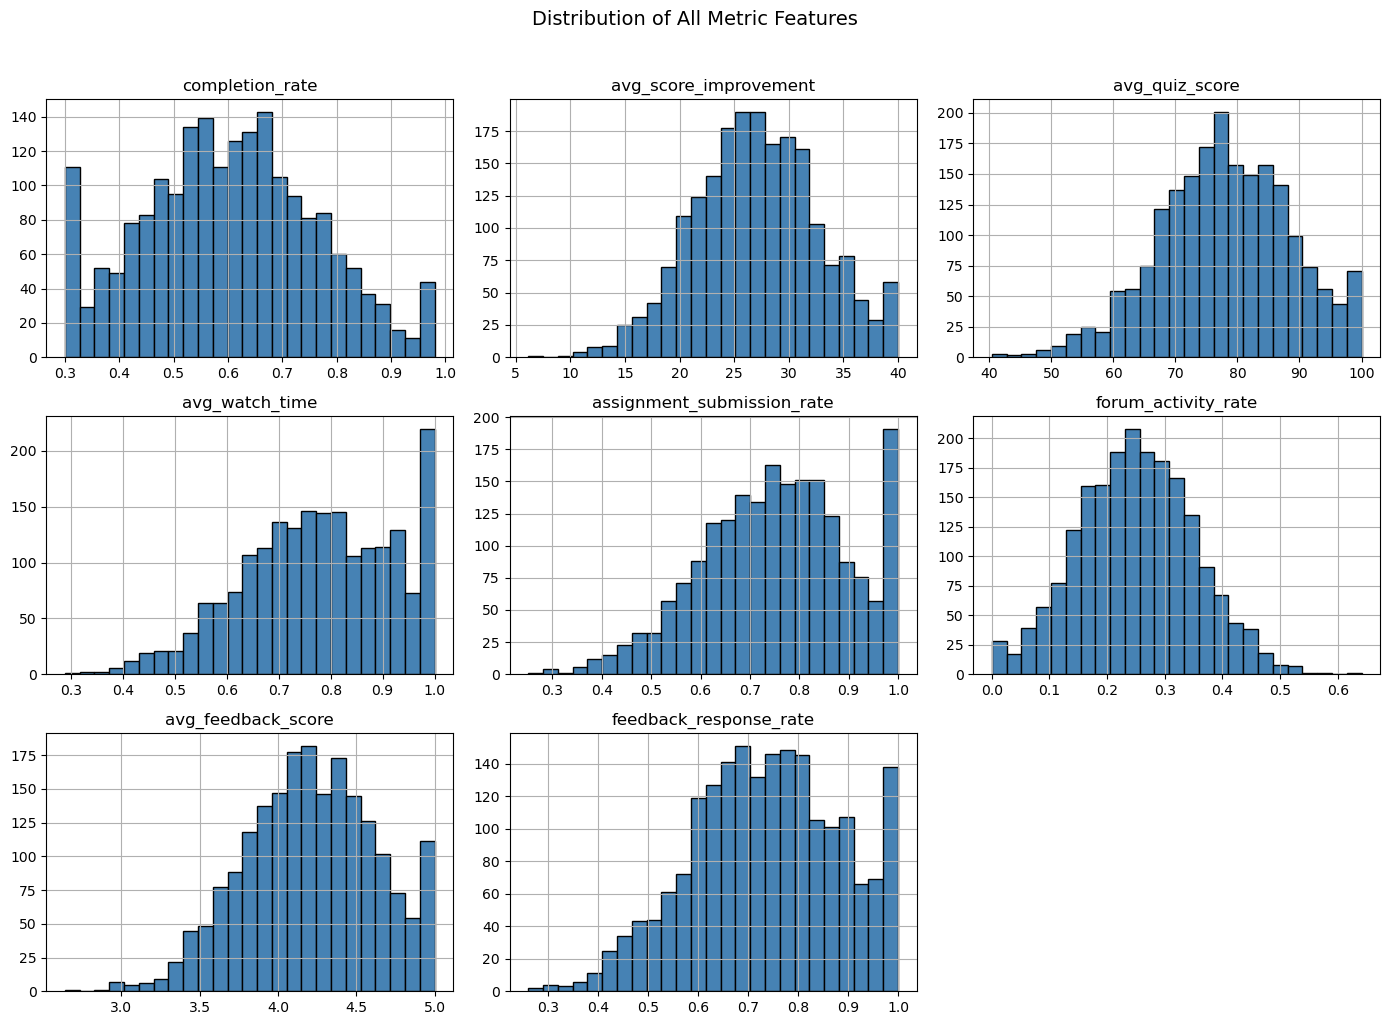

In [12]:
metric_cols = [
    'completion_rate', 'avg_score_improvement', 'avg_quiz_score',
    'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
    'avg_feedback_score', 'feedback_response_rate'
]

df[metric_cols].hist(figsize=(14, 10), bins=25, color='steelblue', edgecolor='black')
plt.suptitle('Distribution of All Metric Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

##### 1.2a Histogram observations
- Completion rate has a spike at 0.3 min value possible floor effect
- average score improvement is normally distributed
- avg watch time and assigment submission shows cieling spikes at 1
- forum_activity_rate is right skewed — consistently low engagement across batches
- avg_feedback_score is left skewed and clustered high — confirms rating inflation

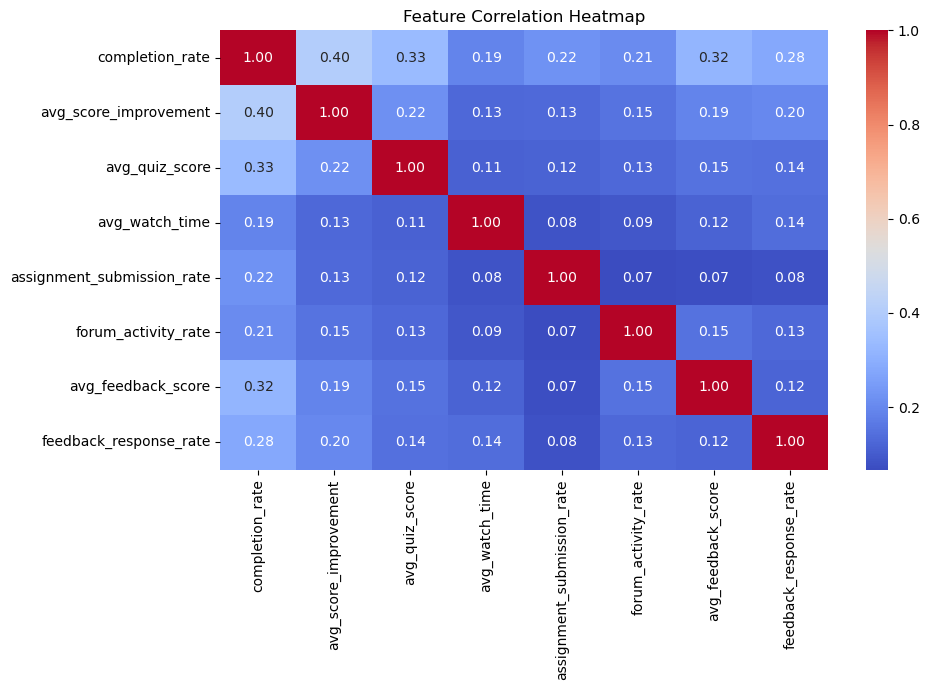

In [13]:
plt.figure(figsize=(10,7))
sns.heatmap(df[metric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

##### 1.2b Correlation Heatmap Observations:
- No severe multicollinearity highest off-diagonal correlation is 0.40 i.e (completion_rate vs avg_score_improvement)
- completion_rate correlates most with avg_score_improvement (0.40), avg_quiz_score (0.33), and avg_feedback_score (0.32)
- Engagement features (watch_time, submission_rate, forum_activity) are largely independent of each other — each adds unique signal

#### 2. Feature Engineering (Defining Instructor Effectiveness Score) 

We can say an instructor is effective is his/her students learns efficiently, stays engaged, feels statisfied.
-  Learner Outcomes: completion_rate, avg_score_improvement, avg_quiz_score
- Engagement: avg_watch_time, assignment_submission_rate, forum_activity_rate  
- Feedback: avg_feedback_score

Weights are assigned based on EDA findings
- Outcome features get highest weight 
- Engagement features get moderate weight 
- Feedback gets lower weight 

In [14]:
# removing dropout columns from main df since it is inverse of completion rate 
df = df.drop(columns = ['dropout_rate'])

print("remaining columns: ",df.columns.tolist())

remaining columns:  ['batch_id', 'instructor_id', 'course_id', 'completion_rate', 'avg_score_improvement', 'avg_quiz_score', 'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate']


In [15]:
# using minmax scalar for scaling values between(0-1)

from sklearn.preprocessing import MinMaxScaler

score_features = [
    'completion_rate',
    'avg_score_improvement',
    'avg_quiz_score',
    'avg_watch_time',
    'assignment_submission_rate',
    'forum_activity_rate',
    'avg_feedback_score'
]

scaler = MinMaxScaler()
df_scaled = df.copy()

df_scaled[score_features] = scaler.fit_transform(df[score_features])

df_scaled[score_features].head(5)

,completion_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score
0,0.000000,0.238373,0.556249,0.683637,0.720811,0.169103,0.477227
1,0.525324,0.493839,0.619419,0.291198,0.998085,0.437599,1.000000
2,0.000000,0.293382,0.657185,0.968987,0.742683,0.322898,0.371797
3,0.499274,0.534901,0.988179,0.784601,0.391839,0.477913,0.664240
4,0.334267,0.736459,0.989825,0.884150,0.820915,0.393519,0.756886


In [16]:
# assigning weights based on EDA findings
# Also creating effectiveness score = sum(columns * respective col weight) 

weights = {
    'completion_rate'           : 0.25,
    'avg_score_improvement'     : 0.25,
    'avg_quiz_score'            : 0.15,
    'avg_watch_time'            : 0.10,
    'assignment_submission_rate': 0.10,
    'forum_activity_rate'       : 0.05,
    'avg_feedback_score'        : 0.10
}

df_scaled['effectiveness_score'] = sum(
    df_scaled[col]* weight for col, weight in weights.items()
)

print(f"Score range: {df_scaled['effectiveness_score'].min():.3f} to {df_scaled['effectiveness_score'].max():.3f}")
df_scaled[['batch_id', 'instructor_id', 'effectiveness_score']].head()


Score range: 0.160 to 0.937


,batch_id,instructor_id,effectiveness_score
0,B_1861,I_044,0.339653
1,B_0354,I_119,0.598512
2,B_1334,I_050,0.396415
3,B_0906,I_024,0.614734
4,B_1290,I_001,0.682026


In [17]:
# creating three tiers "effectiveness tires" [low, medium, high]
# if effectiness_score <= 33% = low, <= 66% medium, else high

low_threshold = df_scaled['effectiveness_score'].quantile(0.33)
highest_threshold = df_scaled['effectiveness_score'].quantile(0.66)

def assign_tier(score):
    if score <= low_threshold:
        return 'Low'
    elif score <= highest_threshold:
        return 'Medium'
    else:
        return 'High'

df_scaled['effectiveness_tier'] = df_scaled['effectiveness_score'].apply(assign_tier)

print("Tier Distribution:")
print(df_scaled['effectiveness_tier'].value_counts())


Tier Distribution:
effectiveness_tier
High      680
Low       660
Medium    660
Name: count, dtype: int64


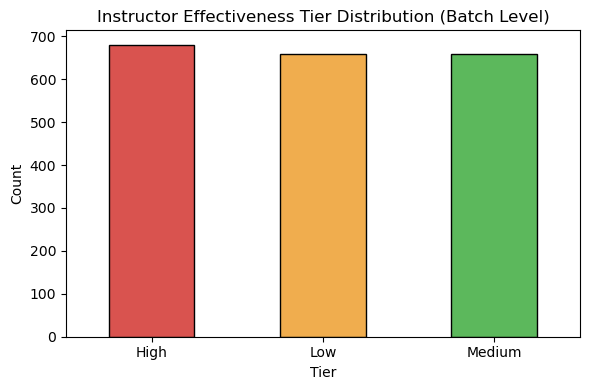

In [18]:
# Instructor Effectiveness Tier Distribution (Batch Level)

plt.figure(figsize=(6, 4))
df_scaled['effectiveness_tier'].value_counts().plot(
    kind='bar', color=['#d9534f','#f0ad4e','#5cb85c'], edgecolor='black'
)
plt.title('Instructor Effectiveness Tier Distribution (Batch Level)')
plt.xlabel('Tier')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Effectiveness Score Observations:

- Score range is 0 to 1 confirms scaling and weighting worked correctly
- Tier distribution is balanced: High(680), Medium(660), Low(660)
- Percentile-based tiering was chosen over fixed thresholds 

#### 3 Aggregate Batch-Level Data to Instructor Level

Since each instructor teaches multiple batches, we aggregate 2000 batch rows 
into 120 instructor-level rows.

Aggregation decisions:
- mean: used for all numeric features — captures overall instructor tendency
- mode: used for effectiveness_tier — most frequent tier across batches
- count: used for batch_id — creates num_batches feature (reliability indicator)

In [19]:
# creating new instructors df by aggregating every instructors data using mean  

feature_col = [
    'completion_rate',
    'avg_score_improvement',
    'avg_quiz_score',
    'avg_watch_time',
    'assignment_submission_rate',
    'forum_activity_rate',
    'avg_feedback_score',
    'effectiveness_score'   
]

instructor_df = df_scaled.groupby('instructor_id')[feature_col].mean().reset_index()

print(f"Shape after aggregation: {instructor_df.shape}")
instructor_df.head()

Shape after aggregation: (120, 9)


,instructor_id,completion_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,effectiveness_score
0,I_001,0.358658,0.605253,0.646055,0.672327,0.635317,0.375209,0.668547,0.554266
1,I_002,0.633639,0.709411,0.693645,0.771799,0.698745,0.451731,0.721621,0.681612
2,I_003,0.688892,0.703843,0.691192,0.745203,0.705706,0.462047,0.766972,0.696753
3,I_004,0.232836,0.495047,0.625592,0.709681,0.677277,0.352917,0.608662,0.493018
4,I_005,0.823158,0.780993,0.762270,0.785317,0.835679,0.520220,0.662095,0.769699


In [20]:
# creating num_batches coln for knowing each instructor's total batches
num_batches = df_scaled.groupby('instructor_id')['batch_id'].count().reset_index(name='num_batches')

print(type(num_batches))
print(num_batches.head())

instructor_df = instructor_df.merge(num_batches, on='instructor_id')
print("\nShape after merge:", instructor_df.shape)

<class 'pandas.core.frame.DataFrame'>
  instructor_id  num_batches
0         I_001           25
1         I_002           20
2         I_003           18
3         I_004           17
4         I_005           19

Shape after merge: (120, 10)


In [21]:
# for each instructors effectiveness_tiers we will use mode as agg function i.e if I_001 has high tier more we select that 

tier_mode = df_scaled.groupby('instructor_id')['effectiveness_tier'].agg(lambda x: x.mode()[0]).reset_index()


In [22]:
instructor_df = instructor_df.merge(tier_mode, on='instructor_id')

print("Final instructor dataframe shape:", instructor_df.shape)
print("\nTier Distribution at Instructor Level:")
print(instructor_df['effectiveness_tier'].value_counts())

Final instructor dataframe shape: (120, 11)

Tier Distribution at Instructor Level:
effectiveness_tier
High      41
Low       41
Medium    38
Name: count, dtype: int64


In [23]:
instructor_df.head(3)

,instructor_id,completion_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,effectiveness_score,num_batches,effectiveness_tier
0,I_001,0.358658,0.605253,0.646055,0.672327,0.635317,0.375209,0.668547,0.554266,25,Medium
1,I_002,0.633639,0.709411,0.693645,0.771799,0.698745,0.451731,0.721621,0.681612,20,High
2,I_003,0.688892,0.703843,0.691192,0.745203,0.705706,0.462047,0.766972,0.696753,18,High


#### Aggregation Results:
- 2000 batch rows successfully collapsed to 120 instructor-level rows
- All features represent instructor's mean performance across all batches
- num_batches added as reliability indicator (range: 7–31)
- effectiveness_tier assigned via mode most frequent tier across batches
- Tier labels are consistent with effectiveness_score values

#### 4 Model building

In [24]:
x = instructor_df.drop(columns=['instructor_id', 'effectiveness_tier', 'effectiveness_score'])

y = instructor_df['effectiveness_tier']

print("Feature shape:", x.shape)
print("Target distribution:\n", y.value_counts())
print("\nFeatures used:", x.columns.tolist())

Feature shape: (120, 8)
Target distribution:
 effectiveness_tier
High      41
Low       41
Medium    38
Name: count, dtype: int64

Features used: ['completion_rate', 'avg_score_improvement', 'avg_quiz_score', 'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate', 'avg_feedback_score', 'num_batches']


In [25]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)
print("Encoded values:", set(y_encoded))

Classes: ['High' 'Low' 'Medium']
Encoded values: {0, 1, 2}


In [26]:
x_train, x_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.2, random_state = 42, stratify=y_encoded)

print("Train size:", x_train.shape)
print("Test size :", x_test.shape)

Train size: (96, 8)
Test size : (24, 8)


In [27]:
model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(x_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [28]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(model, x, y_encoded, cv=cv, scoring='accuracy')


In [29]:
print("Logistic Regression CV Accuracy: {:.3f} ± {:.3f}".format(cv_scores.mean(), cv_scores.std()))


Logistic Regression CV Accuracy: 0.733 ± 0.090


In [30]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(x_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Test Accuracy: 0.75

Classification Report:
              precision    recall  f1-score   support

        High       0.73      1.00      0.84         8
         Low       0.78      0.88      0.82         8
      Medium       0.75      0.38      0.50         8

    accuracy                           0.75        24
   macro avg       0.75      0.75      0.72        24
weighted avg       0.75      0.75      0.72        24



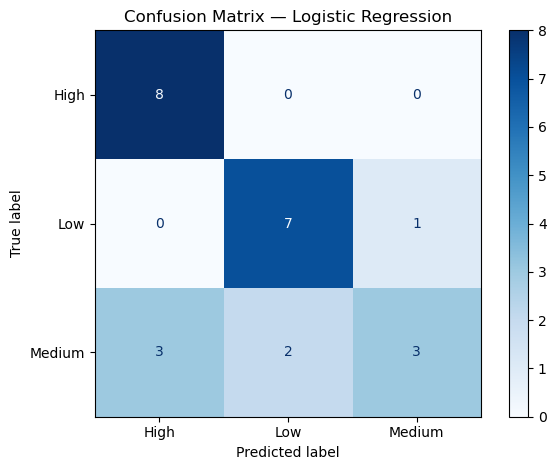

In [31]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

#### 5: Model Evaluation

### Results:
- Test Accuracy: 75% 
- CV Accuracy: 73.3% ± 9% 

### Class-wise Performance:
- High: Perfect recall (1.0): model identifies all high performers correctly
- Low: Strong performance (recall 0.88):  misses only 1 instructor
- Medium: Weakest class (recall 0.38): correctly identifies only 3 out of 8

### Confusion Matrix Insight:
All misclassifications involve the Medium class the model never 
directly confuses High with Low or vice versa. This suggests the 
model has learned meaningful separation between performance extremes.

### Trade-off Discussion:
- High recall for High tier means no high performer goes undetected
- Low recall for Medium means some average instructors get 
  mislabeled as High or Low
- In a real EdTech product, missing a High performer (false negative) 
  is less costly than wrongly labeling a Medium as Low (false positive)

In [32]:
feature_importance = pd.Series(
    np.abs(model.coef_).mean(axis=0),
    index=x.columns
).sort_values(ascending=False)

print("Feature Importance:")
print(feature_importance)


Feature Importance:
completion_rate               1.724627
avg_score_improvement         0.863728
assignment_submission_rate    0.694609
avg_quiz_score                0.685047
avg_feedback_score            0.551205
avg_watch_time                0.513612
forum_activity_rate           0.458351
num_batches                   0.040438
dtype: float64


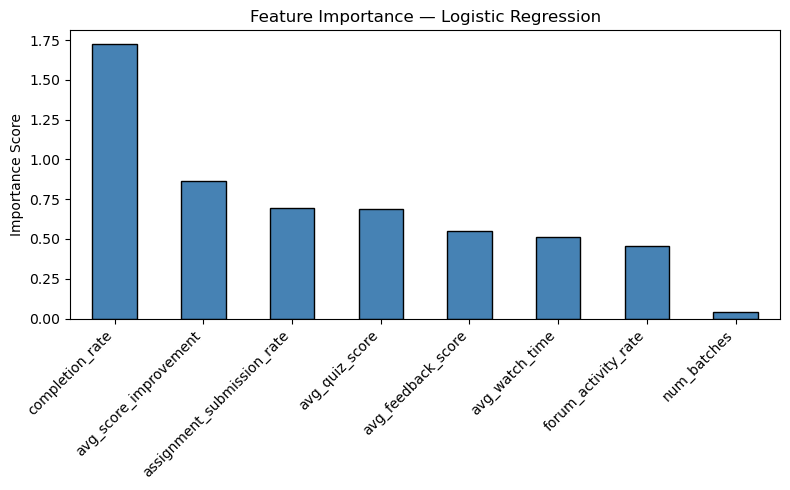

In [33]:
plt.figure(figsize=(8, 5))
feature_importance.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Logistic Regression')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6. Feature Importance & Interpretation

Key findings:
- completion_rate is the strongest predictor — by a large margin
- avg_score_improvement confirms learning outcomes matter most
- Active engagement (assignments) beats passive (watch time)
- Experience (num_batches) has almost zero influence on effectiveness

Platform insight:
Track completion rate in real time as the primary warning signal.
Don't rely on feedback scores alone — too inflated to be decisive.

### 7. Mandatory Analysis Questions

**Q1. Which features most influenced instructor effectiveness, and why?**

completion_rate and avg_score_improvement are the strongest features. completion_rate directly measures student retention — if students aren't 
finishing the course, nothing else compensates. avg_score_improvement 
measures actual learning gain, which is the core purpose of any instructor.

**Q2. Which variables could be misleading or confounded?**
- avg_feedback_score: the score clusters between 3.9-4.5
- avg_watch_time: students can watch videos without actually learning
- forum_activity_rate 

**Q3. How could this model fail in real-world usage?**
- Small dataset (120 instructors): model may not generalize well
- Metrics can be gamed: instructors could lower standards to 
  boost completion rates artificially

**Q4. What additional data would improve this analysis?**
- Course difficulty level (hard, easy, moderate)
- Student prior knowledge
- lec/cohort size per batch
- Instructor teaching style like (interactive, stc)

**Q5. Should this model be used for instructor performance evaluation?**
Not fully but it's useful for identifying which instructors may need help to improve their performance.